<a href="https://colab.research.google.com/github/ananya-247/learning_trajectory/blob/main/Bitcoin_Market_Analysis_Mar2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_703/341623665.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BTC-USD", period="1y")
[*********************100%***********************]  1 of 1 completed


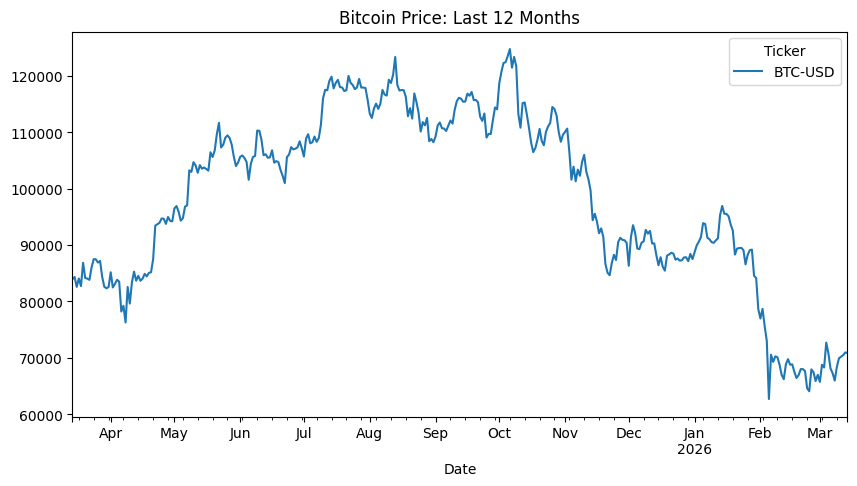

In [1]:
# 1. Install the finance tool
!pip install yfinance

# 2. Import the libraries (the 'toolboxes' we need)
import yfinance as yf
import matplotlib.pyplot as plt

# 3. Download 1 year of Bitcoin data
data = yf.download("BTC-USD", period="1y")

# 4. Create the chart
data['Close'].plot(figsize=(10, 5), title="Bitcoin Price: Last 12 Months")
plt.show()

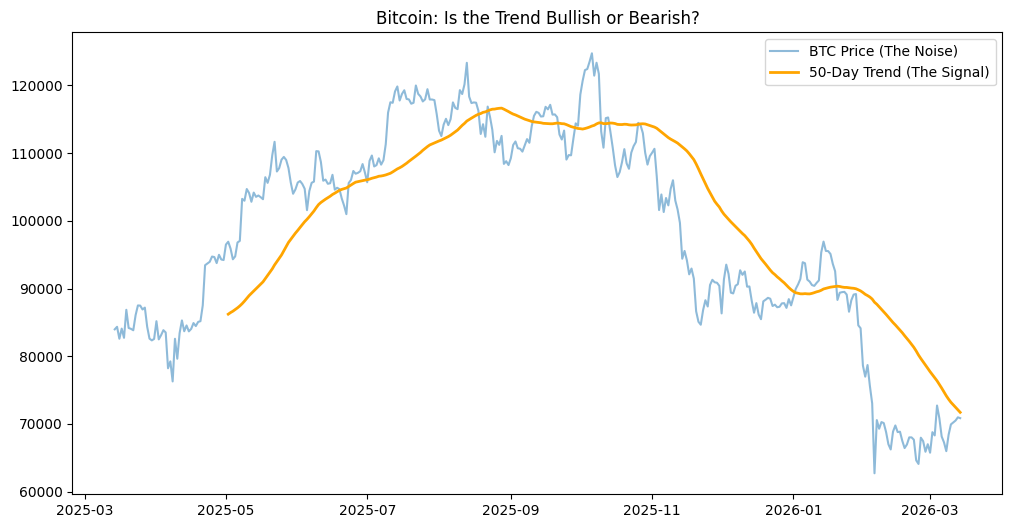

In [2]:
# 1. Calculate the 'Signal' (50-day Moving Average)
data['SMA50'] = data['Close'].rolling(window=50).mean()

# 2. Plot both the real price and the smooth signal
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='BTC Price (The Noise)', alpha=0.5) # alpha makes it slightly transparent
plt.plot(data['SMA50'], label='50-Day Trend (The Signal)', color='orange', linewidth=2)

# 3. Make the chart professional
plt.title("Bitcoin: Is the Trend Bullish or Bearish?")
plt.legend()
plt.show()

In [4]:
# 1. Get the very last price and the very last average value
latest_price = data['Close'].iloc[-1].item() # Convert Series to scalar
latest_trend = data['SMA50'].iloc[-1]

# 2. Calculate the percentage difference
percent_diff = ((latest_price - latest_trend) / latest_trend) * 100

# 3. Print the result clearly
print(f"Current Bitcoin Price: ${latest_price:,.2f}")
print(f"50-Day Average: ${latest_trend:,.2f}")
print(f"Bitcoin is currently {percent_diff:.2f}% {'ABOVE' if percent_diff > 0 else 'BELOW'} its 50-day trend.")

Current Bitcoin Price: $70,848.52
50-Day Average: $71,703.42
Bitcoin is currently -1.19% BELOW its 50-day trend.


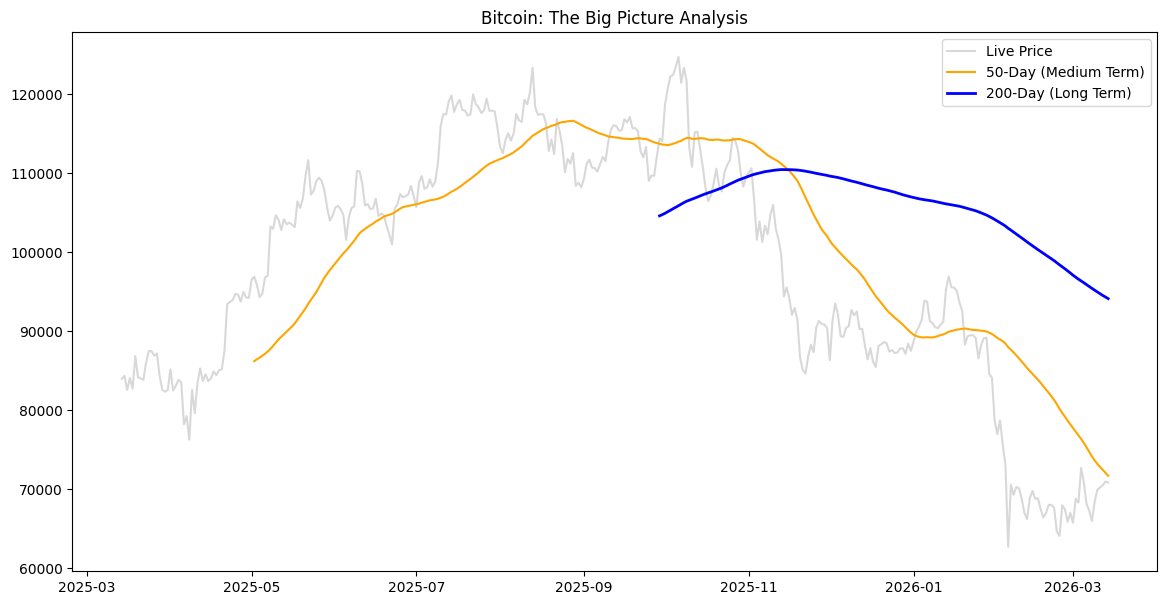

Market Status: DEATH CROSS (Long-term Bearish/Negative)


In [5]:
# 1. Add the Long-Term trend (200 days)
data['SMA200'] = data['Close'].rolling(window=200).mean()

# 2. Create a professional comparison chart
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Live Price', color='gray', alpha=0.3)
plt.plot(data['SMA50'], label='50-Day (Medium Term)', color='orange')
plt.plot(data['SMA200'], label='200-Day (Long Term)', color='blue', linewidth=2)

plt.title("Bitcoin: The Big Picture Analysis")
plt.legend()
plt.show()

# 3. Check for the 'Big' signal
latest_50 = data['SMA50'].iloc[-1].item()
latest_200 = data['SMA200'].iloc[-1].item()

if latest_50 > latest_200:
    print("Market Status: GOLDEN CROSS (Long-term Bullish/Positive)")
else:
    print("Market Status: DEATH CROSS (Long-term Bearish/Negative)")

In [6]:
# 1. Calculate Daily Returns (Percentage change day-to-day)
data['Daily_Return'] = data['Close'].pct_change()

# 2. Calculate Volatility (Standard Deviation of returns over the last 30 days)
volatility = data['Daily_Return'].rolling(window=30).std().iloc[-1].item()

# 3. Print the 'Risk' score
print(f"Current Daily Volatility: {volatility:.4f}")

# Logic to explain the risk
if volatility > 0.03:
    print("Risk Level: HIGH (Buckle up, the price is swinging wildly)")
elif volatility > 0.01:
    print("Risk Level: MEDIUM (Standard crypto movements)")
else:
    print("Risk Level: LOW (Surprisingly stable for Bitcoin)")

Current Daily Volatility: 0.0267
Risk Level: MEDIUM (Standard crypto movements)


In [9]:
import pandas as pd

# 1. Download S&P 500 data (Ticker: ^GSPC)
sp500_series = yf.download("^GSPC", period="1y")['Close']
btc_series = yf.download("BTC-USD", period="1y")['Close']

# Align the two series by their index (date) and drop rows with NaNs
# This is crucial because S&P 500 trades fewer days than Bitcoin
combined_data = pd.concat([btc_series, sp500_series], axis=1).dropna()
combined_data.columns = ['BTC_Close', 'SP500_Close']

# 2. Calculate the correlation (Relationship)
# 1.0 = Moving in perfect sync | -1.0 = Moving in opposite directions | 0 = No relationship
correlation = combined_data['BTC_Close'].corr(combined_data['SP500_Close'])

print(f"Correlation between Bitcoin and S&P 500: {correlation:.2f}")

if correlation > 0.7:
    print("Insight: High Correlation. Bitcoin is moving in sync with the stock market.")
elif correlation < 0.3:
    print("Insight: Low Correlation. Bitcoin is 'decoupled' and doing its own thing.")
else:
    print("Insight: Moderate Correlation. They share some common ground.")

/tmp/ipykernel_703/1382982260.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_series = yf.download("^GSPC", period="1y")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_703/1382982260.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc_series = yf.download("BTC-USD", period="1y")['Close']
[*********************100%***********************]  1 of 1 completed

Correlation between Bitcoin and S&P 500: -0.07
Insight: Low Correlation. Bitcoin is 'decoupled' and doing its own thing.


Project Goal: Analyze Bitcoin's trend and its relationship to the S&P 500.

Key Finding: BTC is in a Death Cross but remains uncorrelated (-0.07) to the stock market.

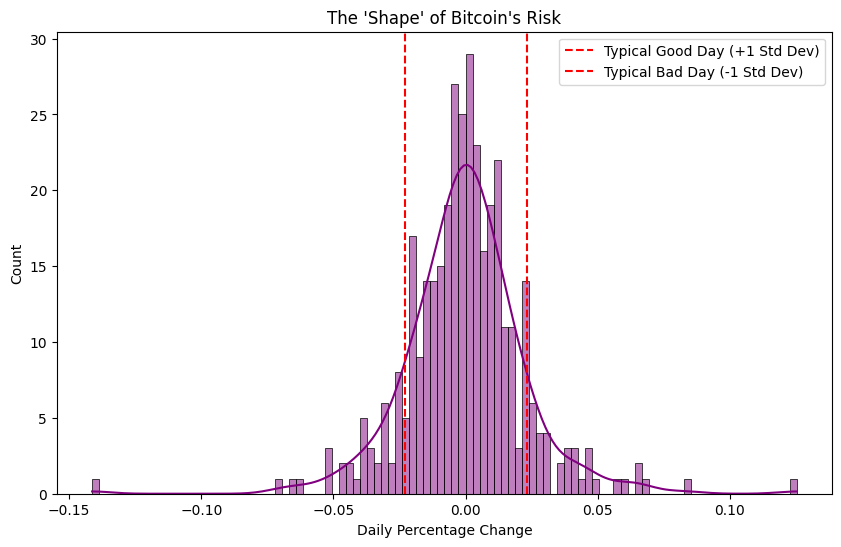

In the last year, there were 4 'Extreme' days (Black Swans).


In [10]:
import seaborn as sns # A library for beautiful statistical charts

# 1. Clean up the daily returns (remove the first row which is empty)
returns = data['Daily_Return'].dropna()

# 2. Create a Histogram (Shows how often certain % changes happen)
plt.figure(figsize=(10, 6))
sns.histplot(returns, kde=True, bins=100, color='purple')

# 3. Add lines for the "Standard Deviation" (The Math-to-Info Bridge)
std_dev = returns.std()
plt.axvline(std_dev, color='red', linestyle='--', label='Typical Good Day (+1 Std Dev)')
plt.axvline(-std_dev, color='red', linestyle='--', label='Typical Bad Day (-1 Std Dev)')

plt.title("The 'Shape' of Bitcoin's Risk")
plt.xlabel("Daily Percentage Change")
plt.legend()
plt.show()

# 4. Count 'Extreme' days (Black Swans)
extreme_days = returns[abs(returns) > (3 * std_dev)].count()
print(f"In the last year, there were {extreme_days} 'Extreme' days (Black Swans).")